# 🔬 Experimento de Robustez — Pipeline VertebraPromptNet + BoxRefiner + MedSAM
**Proyecto:** Segmentación automática de vértebras T1–L5  
**Modelos:** VertebraPromptNet → BoxRefiner → MedSAM

**Objetivo:** Medir robustez ante radiografías recortadas y comparar con pipeline anterior

## Pipeline
```
Imagen → VertebraPromptNet → cajas brutas → BoxRefiner → cajas refinadas → MedSAM → máscara
```

## Modos de evaluación
| Modo | Descripción |
|---|---|
| `auto` | Pipeline completo: VertebraPromptNet + BoxRefiner + MedSAM |
| `auto_norefiner` | Sin BoxRefiner: VertebraPromptNet + MedSAM (mide aporte del refiner) |
| `gt_box` | Cajas del GT + MedSAM (upper-bound) |


In [1]:
# ==== CELDA 1 — INSTALACIÓN ====
import os
if not os.path.exists('MedSAM'):
    !git clone https://github.com/bowang-lab/MedSAM.git
if not os.path.exists('segment-anything'):
    !git clone https://github.com/facebookresearch/segment-anything.git
    %cd segment-anything && pip install -e . -q && %cd ..
!pip install -q segment-anything monai opencv-python-headless tqdm pandas matplotlib
import sys
sys.path.insert(0, 'MedSAM')
print('✅ Dependencias listas')


Cloning into 'MedSAM'...
remote: Enumerating objects: 967, done.
remote: Total 967 (delta 0), reused 0 (delta 0), pack-reused 967 (from 1)
Receiving objects: 100% (967/967), 62.91 MiB | 19.17 MiB/s, done.
Resolving deltas: 100% (474/474), done.
Cloning into 'segment-anything'...
remote: Enumerating objects: 304, done.
remote: Total 304 (delta 0), reused 0 (delta 0), pack-reused 304 (from 1)
Receiving objects: 100% (304/304), 18.31 MiB | 15.46 MiB/s, done.
Resolving deltas: 100% (161/161), done.
[Errno 2] No such file or directory: 'segment-anything && pip install -e . -q && %cd ..'
/content
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 45.0 MB/s eta 0:00:00
✅ Dependencias listas


In [2]:
# ==== CELDA 2 — MONTAR GOOGLE DRIVE ====
from google.colab import drive
import os
if os.path.exists('/content/drive/MyDrive'):
    print('✅ Drive ya montado')
else:
    drive.mount('/content/drive')
    print('✅ Drive montado')


Mounted at /content/drive
✅ Drive montado


In [6]:
# ==== CELDA 3 — ⚙️ CONFIGURACIÓN (EDITAR SOLO AQUÍ) ====
from pathlib import Path

# Rutas del dataset
MEDSAM_DATA_ROOT = Path('/content/drive/MyDrive/dataset_procesado/medsam')
LABELS_DICT_PATH = Path('/content/drive/MyDrive/MaIA_Scoliosis_Dataset/labels_dictionary.json')

# Checkpoints nuevos (estrategia ganadora de Felipe)
CKPT_VERTEBRAPROMPT = Path('/content/drive/MyDrive/MaIA_Scoliosis_Dataset/vertebraprompt_net_auxiliar_best.pt')
CKPT_BOX_REFINER    = Path('/content/drive/MyDrive/MaIA_Scoliosis_Dataset/box_refiner_best.pt')
CKPT_MEDSAM_NEW     = Path('/content/drive/MyDrive/MaIA_Scoliosis_Dataset/medsam_decoder_encoder_parcial_entrenado_vertebraprompt_aux.pt')
MEDSAM_BASE         = Path('/content/drive/MyDrive/MaIA_Scoliosis_Dataset/medsam_vit_b.pth')

# Salida
ROBUST_DIR = Path('/content/drive/MyDrive/robustez_vertebraprompt_boxrefiner')
ROBUST_DIR.mkdir(parents=True, exist_ok=True)
(ROBUST_DIR / 'visualizaciones').mkdir(exist_ok=True)

# Pacientes (None = todos los 38 del test)
#PATIENT_IDS_EVAL = ['N_11', 'N_22', 'N_30', 'S_101', 'S_108', 'S_125']
PATIENT_IDS_EVAL = None
SPLIT_EVAL       = 'test'
SEED             = 42

# Parámetros del pipeline (igual al notebook de Felipe)
IMG_SIZE               = 512
BASE_CH                = 32
BOX_EXPAND_W           = 1.12
BOX_EXPAND_H           = 1.12
TOP_PICOS              = 90
MIN_DIST_PICOS         = 8
MAX_CANDIDATOS         = 120
N_CAJAS_CAMINO         = 17
MAX_GAP_REL_DY         = 2.40
TARGET_BOX_EXPAND_W    = 1.10
TARGET_BOX_EXPAND_H    = 1.12
ETIQUETADO_MODO        = 'top_anchor'
SHIFTS_ANATOMICOS      = list(range(-6, 7))

# Parámetros BoxRefiner (igual al notebook de Felipe)
BOX_REFINER_SIZE          = 192
BOX_REFINER_CONTEXT_FRAC  = 0.85
BOX_REFINER_BLEND         = 0.80
BOX_REFINER_MAX_ABS_DXY   = 0.45
BOX_REFINER_MAX_ABS_LOG_SCALE = 0.45

print('✅ Configuración lista')
print(f'   VertebraPromptNet : {CKPT_VERTEBRAPROMPT.name}')
print(f'   BoxRefiner        : {CKPT_BOX_REFINER.name}')
print(f'   MedSAM nuevo      : {CKPT_MEDSAM_NEW.name}')
print(f'   Salida            : {ROBUST_DIR}')


✅ Configuración lista
   VertebraPromptNet : vertebraprompt_net_auxiliar_best.pt
   BoxRefiner        : box_refiner_best.pt
   MedSAM nuevo      : medsam_decoder_encoder_parcial_entrenado_vertebraprompt_aux.pt
   Salida            : /content/drive/MyDrive/robustez_vertebraprompt_boxrefiner


In [7]:
# ==== CELDA 4 — IMPORTS ====
import json, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if DEVICE.type != 'cuda':
    raise RuntimeError('GPU requerida. Entorno de ejecución → Cambiar tipo → T4')
print(f'✅ GPU: {torch.cuda.get_device_name(0)}')


✅ GPU: Tesla T4


In [8]:
# ==== CELDA 5 — DICCIONARIO DE ETIQUETAS ====
with open(LABELS_DICT_PATH, 'r', encoding='utf-8') as f:
    LABELS_DICT = json.load(f)

MAPEO_ID        = {int(k): v for k, v in LABELS_DICT['multiclass_id_png'].items()}
CLASES_OBJETIVO = [MAPEO_ID[i] for i in range(6, 23)]  # T1=6 ... L5=22
N_CLASES        = len(CLASES_OBJETIVO)                   # 17
VERTEBRA_TO_ID  = {nombre: idx for idx, nombre in MAPEO_ID.items() if idx in range(6, 23)}
ID_TO_VERTEBRA  = {idx: nombre for nombre, idx in VERTEBRA_TO_ID.items()}
SPLITS          = ['train', 'val', 'test']
EXTS_IMG        = ['.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff']
print(f'✅ {N_CLASES} clases: {CLASES_OBJETIVO}')


✅ 17 clases: ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12', 'L1', 'L2', 'L3', 'L4', 'L5']


In [9]:
# ==== CELDA 6 — CARGA DE DATOS ====
def buscar_archivo_por_stem(carpeta, stem):
    for ext in EXTS_IMG:
        p = carpeta / f'{stem}{ext}'
        if p.exists(): return p
    return None

def resolver_paths_split(split):
    d = MEDSAM_DATA_ROOT / split
    pp = d / 'prompts.json'
    id_ = next((d/s for s in ['images','imgs','image'] if (d/s).is_dir()), None)
    md  = next((d/s for s in ['masks','labels','mask','annotations'] if (d/s).is_dir()), None)
    if not id_ or not md or not pp.exists(): raise FileNotFoundError(f'Split incompleto: {d}')
    return {'image_dir': id_, 'mask_dir': md, 'prompts_path': pp}

def cargar_imagen(path): return np.array(Image.open(path).convert('RGB'))
def cargar_mascara(path): return np.array(Image.open(path)).astype(np.int32)

def normalizar_prompts(ps):
    out = {}
    for item in ps:
        pid = str(item.get('patient_id'))
        sub = {}
        it = item.get('prompts', {})
        it = it.values() if isinstance(it, dict) else it
        for info in it:
            if not isinstance(info, dict): continue
            v = str(info.get('vertebra', '')).upper()
            if v in CLASES_OBJETIVO and 'bbox_xyxy' in info: sub[v] = dict(info)
        if sub: out[pid] = sub
    return out

def resolver_paths_muestra(split, pid):
    si = SPLIT_INFO[split]
    pi = buscar_archivo_por_stem(si['image_dir'], pid)
    pm = buscar_archivo_por_stem(si['mask_dir'], pid)
    if not pi or not pm: raise FileNotFoundError(f'No encontré {pid}')
    return pi, pm

def vertebras_presentes_en_mascara(mask):
    ids = sorted(int(v) for v in np.unique(mask) if int(v) in ID_TO_VERTEBRA)
    return [ID_TO_VERTEBRA[i] for i in ids]

SPLIT_INFO   = {s: resolver_paths_split(s) for s in SPLITS}
PROMPTS_DICC = {}
for s in SPLITS:
    with open(SPLIT_INFO[s]['prompts_path'], 'r', encoding='utf-8') as f:
        PROMPTS_DICC[s] = normalizar_prompts(json.load(f))

for s in SPLITS: print(f'{s}: {len(PROMPTS_DICC[s])} pacientes')


train: 173 pacientes
val: 37 pacientes
test: 38 pacientes


In [10]:
# ==== CELDA 7 — PLANTILLA MEDIANA DE BBOXES ====
def construir_template_bbox_train():
    filas = []
    for pid, ps in PROMPTS_DICC['train'].items():
        for v, info in ps.items():
            x0,y0,x1,y1 = info['bbox_xyxy']
            filas.append({'vertebra':v,'id_real':VERTEBRA_TO_ID[v],
                'cx_rel':((x0+x1)/2)/1024,'cy_rel':((y0+y1)/2)/1024,
                'w_rel':(x1-x0)/1024,'h_rel':(y1-y0)/1024})
    df = pd.DataFrame(filas)
    return (df.groupby(['vertebra','id_real'],as_index=False)
            .agg(cx_rel=('cx_rel','median'),cy_rel=('cy_rel','median'),
                 w_rel=('w_rel','median'),h_rel=('h_rel','median'))
            .sort_values('id_real').reset_index(drop=True))

template_bbox = construir_template_bbox_train()
print(f'✅ Plantilla lista: {len(template_bbox)} vértebras')


✅ Plantilla lista: 17 vértebras


In [11]:
# ==== CELDA 8 — ARQUITECTURAS (VertebraPromptNet + BoxRefinerNet) ====

class ConvBlock(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ic,oc,3,padding=1,bias=False),nn.BatchNorm2d(oc),nn.SiLU(True),
            nn.Conv2d(oc,oc,3,padding=1,bias=False),nn.BatchNorm2d(oc),nn.SiLU(True))
    def forward(self,x): return self.net(x)


class VertebraPromptNet(nn.Module):
    """U-Net multi-tarea con cabeza de calor anatómica por clase (nueva vs CenterNetLite)."""
    def __init__(self, base=BASE_CH):
        super().__init__()
        self.e1=ConvBlock(1,base);self.e2=ConvBlock(base,base*2)
        self.e3=ConvBlock(base*2,base*4);self.e4=ConvBlock(base*4,base*6)
        self.b=ConvBlock(base*6,base*8)
        self.u4=ConvBlock(base*8+base*6,base*6);self.u3=ConvBlock(base*6+base*4,base*4)
        self.u2=ConvBlock(base*4+base*2,base*2);self.u1=ConvBlock(base*2+base,base)
        self.heat_head       = nn.Conv2d(base,1,1)          # calor general
        self.class_heat_head = nn.Conv2d(base,N_CLASES,1)   # calor por clase (NUEVO)
        self.wh_head         = nn.Conv2d(base,2,1)
        self.off_head        = nn.Conv2d(base,2,1)
        self.presence_head   = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),nn.Flatten(),nn.Linear(base*8,N_CLASES))
    def forward(self,x):
        e1=self.e1(x);e2=self.e2(F.max_pool2d(e1,2))
        e3=self.e3(F.max_pool2d(e2,2));e4=self.e4(F.max_pool2d(e3,2))
        b=self.b(F.max_pool2d(e4,2))
        def up(t,ref): return F.interpolate(t,size=ref.shape[-2:],mode='bilinear',align_corners=False)
        u4=self.u4(torch.cat([up(b,e4),e4],1));u3=self.u3(torch.cat([up(u4,e3),e3],1))
        u2=self.u2(torch.cat([up(u3,e2),e2],1));u1=self.u1(torch.cat([up(u2,e1),e1],1))
        return {'heat':self.heat_head(u1),'class_heat':self.class_heat_head(u1),
                'wh':self.wh_head(u1),'off':self.off_head(u1),'presence':self.presence_head(b)}


class BoxRefinerNet(nn.Module):
    """CNN ligera que predice 4 deltas (dx,dy,dw,dh) para corregir cada caja."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            ConvBlock(2,24), nn.MaxPool2d(2),
            ConvBlock(24,48), nn.MaxPool2d(2),
            ConvBlock(48,96), nn.MaxPool2d(2),
            ConvBlock(96,128),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(0.15),
            nn.Linear(128,96), nn.SiLU(True),
            nn.Linear(96,4),
        )
    def forward(self,x):
        out = self.net(x)
        dxy = torch.tanh(out[:,:2]) * BOX_REFINER_MAX_ABS_DXY
        dwh = torch.tanh(out[:,2:]) * BOX_REFINER_MAX_ABS_LOG_SCALE
        return torch.cat([dxy,dwh],dim=1)


print('✅ Arquitecturas definidas')
vpn = VertebraPromptNet()
brn = BoxRefinerNet()
print(f'   VertebraPromptNet: {sum(p.numel() for p in vpn.parameters())/1e6:.2f}M parámetros')
print(f'   BoxRefinerNet    : {sum(p.numel() for p in brn.parameters())/1e6:.3f}M parámetros')
del vpn, brn


✅ Arquitecturas definidas
   VertebraPromptNet: 3.69M parámetros
   BoxRefinerNet    : 0.433M parámetros


In [12]:
# ==== CELDA 9 — CARGAR CHECKPOINTS ====
from segment_anything import sam_model_registry, SamPredictor

def cargar_state_dict(ckpt):
    for k in ['model','model_state_dict','state_dict']:
        if isinstance(ckpt,dict) and k in ckpt: return ckpt[k]
    return ckpt

# 9a. VertebraPromptNet
detector = VertebraPromptNet(base=BASE_CH).to(DEVICE)
ckpt = torch.load(CKPT_VERTEBRAPROMPT, map_location=DEVICE)
miss,unex = detector.load_state_dict(cargar_state_dict(ckpt), strict=False)
detector.eval()
print(f'✅ VertebraPromptNet | faltantes:{len(miss)} | inesperadas:{len(unex)}')

# 9b. BoxRefinerNet
box_refiner = BoxRefinerNet().to(DEVICE)
ckpt_br = torch.load(CKPT_BOX_REFINER, map_location=DEVICE)
miss_br,unex_br = box_refiner.load_state_dict(cargar_state_dict(ckpt_br), strict=False)
box_refiner.eval()
print(f'✅ BoxRefinerNet     | faltantes:{len(miss_br)} | inesperadas:{len(unex_br)}')

# 9c. MedSAM (base + fine-tuning acoplado a VertebraPromptNet)
torch.cuda.empty_cache()
medsam_model = sam_model_registry['vit_b'](checkpoint=str(MEDSAM_BASE)).to(DEVICE)
ckpt_m = torch.load(CKPT_MEDSAM_NEW, map_location=DEVICE)
miss_m,unex_m = medsam_model.load_state_dict(cargar_state_dict(ckpt_m), strict=False)
medsam_model.eval()
predictor = SamPredictor(medsam_model)
print(f'✅ MedSAM nuevo      | faltantes:{len(miss_m)} | inesperadas:{len(unex_m)}')


✅ VertebraPromptNet | faltantes:0 | inesperadas:0
✅ BoxRefinerNet     | faltantes:0 | inesperadas:0
✅ MedSAM nuevo      | faltantes:0 | inesperadas:0


In [13]:
# ==== CELDA 10 — FUNCIONES DE INFERENCIA VertebraPromptNet ====
def imagen_inferencia_tensor(img_rgb):
    g = np.array(Image.fromarray(img_rgb).convert('L')
                 .resize((IMG_SIZE,IMG_SIZE),Image.BILINEAR)).astype(np.float32)
    p1,p99 = np.percentile(g,[1,99.5])
    g = np.clip((g-p1)/(p99-p1+1e-6),0,1)
    return torch.from_numpy(g[None,None,...].astype(np.float32)).to(DEVICE)

@torch.no_grad()
def predecir_outputs(img_rgb):
    detector.eval()
    out = detector(imagen_inferencia_tensor(img_rgb))
    return {'heat':torch.sigmoid(out['heat'])[0,0].cpu().numpy(),
            'wh':torch.sigmoid(out['wh'])[0].cpu().numpy(),
            'off':torch.sigmoid(out['off'])[0].cpu().numpy(),
            'presence':torch.sigmoid(out['presence'])[0].cpu().numpy()}

def extraer_picos(sm, n=TOP_PICOS, md=MIN_DIST_PICOS, thr_r=0.12):
    work=sm.astype(np.float32).copy(); picos=[]
    mx=float(work.max())
    if mx<=0: return picos
    thr=max(mx*thr_r,float(np.percentile(work,90)))
    for _ in range(n):
        idx=int(np.argmax(work)); y,x=np.unravel_index(idx,work.shape)
        sc=float(work[y,x])
        if sc<thr: break
        picos.append({'x':int(x),'y':int(y),'score':sc})
        work[max(0,y-md):min(work.shape[0],y+md+1),
             max(0,x-md):min(work.shape[1],x+md+1)]=-np.inf
    return picos

def seleccionar_camino_dp(cands, n_pasos=N_CAJAS_CAMINO, mgr=MAX_GAP_REL_DY):
    if not cands: raise RuntimeError('Sin candidatos')
    cands=sorted(cands,key=lambda c:(c['y'],c['x']))[:MAX_CANDIDATOS]
    n=len(cands); k=min(n_pasos,n)
    if k<=0: raise RuntimeError('Sin candidatos suficientes')
    xs=np.array([c['x'] for c in cands],np.float32)
    ys=np.array([c['y'] for c in cands],np.float32)
    sc=np.array([c['score'] for c in cands],np.float32)
    tmpl=template_bbox.sort_values('id_real').reset_index(drop=True)
    cy_t=tmpl['cy_rel'].to_numpy(np.float32)*IMG_SIZE
    dy_t=np.diff(cy_t); dy_d=float(np.median(dy_t))
    dp=np.full((k,n),-1e9,np.float32); prev=np.full((k,n),-1,np.int32)
    dp[0]=sc
    for j in range(1,k):
        ed=float(dy_t[j-1]) if j-1<len(dy_t) else dy_d
        ed=max(ed,4.0); mg=max(3.0,ed*0.35); Mg=max(mg+1.0,ed*mgr)
        for i in range(n):
            dy=ys[i]-ys[:i]; vl=(dy>=mg)&(dy<=Mg)
            if not vl.any(): continue
            dx=np.abs(xs[i]-xs[:i])
            tr=dp[j-1,:i]-0.34*np.abs(dy-ed)/ed-0.08*dx/max(IMG_SIZE*0.22,1.0)
            tr[~vl]=-1e9; bt=int(np.argmax(tr))
            dp[j,i]=sc[i]+tr[bt]; prev[j,i]=bt
    end=int(np.argmax(dp[k-1]))
    if dp[k-1,end]<-1e8 and mgr<8.0:
        return seleccionar_camino_dp(cands,n_pasos=n_pasos,mgr=8.0)
    path=[end]
    for j in range(k-1,0,-1):
        end=int(prev[j,end])
        if end<0: break
        path.append(end)
    path=path[::-1]
    if len(path)!=k:
        path=sorted(np.argsort(sc)[-k:].tolist(),key=lambda i:ys[i])
    return [cands[i] for i in path]

def expandir_bbox_1024(bbox,fw=1.0,fh=1.0):
    x0,y0,x1,y1=[float(v) for v in bbox]
    cx,cy=(x0+x1)/2,(y0+y1)/2
    bw=max(1.0,(x1-x0)*fw); bh=max(1.0,(y1-y0)*fh)
    return [float(np.clip(cx-bw/2,0,1023)),float(np.clip(cy-bh/2,0,1023)),
            float(np.clip(cx+bw/2,0,1023)),float(np.clip(cy+bh/2,0,1023))]

def construir_prompts_desde_camino(camino,labels,wh_map):
    prompts={}
    for centro,label in zip(camino,labels):
        cx_i=centro['x']/IMG_SIZE*1024; cy_i=centro['y']/IMG_SIZE*1024
        bwr=float(wh_map[0,centro['y'],centro['x']])
        bhr=float(wh_map[1,centro['y'],centro['x']])
        tmpl_r=template_bbox[template_bbox['vertebra']==label]
        if len(tmpl_r)>0 and (bwr<0.01 or bwr>0.40): bwr=float(tmpl_r['w_rel'].iloc[0])
        if len(tmpl_r)>0 and (bhr<0.01 or bhr>0.40): bhr=float(tmpl_r['h_rel'].iloc[0])
        bw=bwr*1024*BOX_EXPAND_W; bh=bhr*1024*BOX_EXPAND_H
        bbox=expandir_bbox_1024([cx_i-bw/2,cy_i-bh/2,cx_i+bw/2,cy_i+bh/2],
                                 fw=TARGET_BOX_EXPAND_W,fh=TARGET_BOX_EXPAND_H)
        prompts[label]={'vertebra':label,'bbox_xyxy':bbox,'confianza_nn':float(centro['score'])}
    return prompts

def prompts_desde_imagen(img_rgb, modo='top_anchor'):
    out=predecir_outputs(img_rgb)
    cands=extraer_picos(out['heat'])
    if len(cands)<3: return {}
    try: camino=seleccionar_camino_dp(cands)
    except RuntimeError: return {}
    labels=(CLASES_OBJETIVO[:len(camino)] if modo=='top_anchor'
            else CLASES_OBJETIVO[max(0,N_CLASES-len(camino)):])
    return construir_prompts_desde_camino(camino,labels,out['wh'])

print('✅ Funciones de inferencia VertebraPromptNet listas')


✅ Funciones de inferencia VertebraPromptNet listas


In [14]:
# ==== CELDA 11 — FUNCIONES BoxRefiner ====
def bbox_clip(bbox, H, W):
    x0,y0,x1,y1 = [float(v) for v in bbox]
    return [float(np.clip(x0,0,W-1)),float(np.clip(y0,0,H-1)),
            float(np.clip(x1,0,W-1)),float(np.clip(y1,0,H-1))]

def centro_bbox_xyxy(bbox):
    x0,y0,x1,y1=[float(v) for v in bbox]
    return (x0+x1)/2,(y0+y1)/2

def bbox_wh_xyxy(bbox):
    x0,y0,x1,y1=[float(v) for v in bbox]
    return max(x1-x0,1.0),max(y1-y0,1.0)

def expandir_bbox_contexto(bbox,img_shape,frac=BOX_REFINER_CONTEXT_FRAC):
    H,W=img_shape[:2]
    x0,y0,x1,y1=[float(v) for v in bbox]
    cx,cy=(x0+x1)/2,(y0+y1)/2
    bw,bh=max(x1-x0,2.0),max(y1-y0,2.0)
    side=max(bw,bh)*(1.0+float(frac))
    return bbox_clip([cx-side/2,cy-side/2,cx+side/2,cy+side/2],H,W)

def aplicar_delta_bbox(bbox_pred,delta,img_shape,blend=BOX_REFINER_BLEND):
    H,W=img_shape[:2]
    dx,dy,dw,dh=[float(v) for v in delta]
    dx=np.clip(dx,-BOX_REFINER_MAX_ABS_DXY,BOX_REFINER_MAX_ABS_DXY)*blend
    dy=np.clip(dy,-BOX_REFINER_MAX_ABS_DXY,BOX_REFINER_MAX_ABS_DXY)*blend
    dw=np.clip(dw,-BOX_REFINER_MAX_ABS_LOG_SCALE,BOX_REFINER_MAX_ABS_LOG_SCALE)*blend
    dh=np.clip(dh,-BOX_REFINER_MAX_ABS_LOG_SCALE,BOX_REFINER_MAX_ABS_LOG_SCALE)*blend
    cx,cy=centro_bbox_xyxy(bbox_pred)
    bw,bh=bbox_wh_xyxy(bbox_pred)
    cx2=cx+dx*bw; cy2=cy+dy*bh
    bw2=bw*np.exp(dw); bh2=bh*np.exp(dh)
    return bbox_clip([cx2-bw2/2,cy2-bh2/2,cx2+bw2/2,cy2+bh2/2],H,W)

def box_refiner_tensor(img_rgb,bbox_pred):
    """Prepara el tensor de entrada para BoxRefinerNet: [imagen_crop, mascara_bbox]."""
    ctx=expandir_bbox_contexto(bbox_pred,img_rgb.shape)
    x0,y0,x1,y1=ctx
    crop=Image.fromarray(img_rgb).convert('L').crop(
        (int(x0),int(y0),int(x1)+1,int(y1)+1)).resize(
        (BOX_REFINER_SIZE,BOX_REFINER_SIZE),Image.BILINEAR)
    arr=np.asarray(crop).astype(np.float32)
    p1,p99=np.percentile(arr,[1,99.5])
    arr=np.clip((arr-p1)/(p99-p1+1e-6),0,1)
    mask_box=np.zeros((BOX_REFINER_SIZE,BOX_REFINER_SIZE),np.float32)
    bx0,by0,bx1,by1=[float(v) for v in bbox_pred]
    sx=BOX_REFINER_SIZE/max(x1-x0+1,1)
    sy=BOX_REFINER_SIZE/max(y1-y0+1,1)
    rx0=int(np.clip(round((bx0-x0)*sx),0,BOX_REFINER_SIZE-1))
    rx1=int(np.clip(round((bx1-x0)*sx),0,BOX_REFINER_SIZE-1))
    ry0=int(np.clip(round((by0-y0)*sy),0,BOX_REFINER_SIZE-1))
    ry1=int(np.clip(round((by1-y0)*sy),0,BOX_REFINER_SIZE-1))
    if rx1>rx0 and ry1>ry0: mask_box[ry0:ry1+1,rx0:rx1+1]=1.0
    return torch.from_numpy(np.stack([arr,mask_box],axis=0).astype(np.float32))

@torch.no_grad()
def refinar_prompts(prompts_auto, img_rgb):
    """Aplica BoxRefiner a cada caja del diccionario de prompts."""
    box_refiner.eval()
    refinados={}
    for label,info in prompts_auto.items():
        bbox_pred=[int(round(float(v))) for v in info['bbox_xyxy']]
        x=box_refiner_tensor(img_rgb,bbox_pred)[None].to(DEVICE)
        delta=box_refiner(x)[0].detach().cpu().numpy()
        bbox_ref=aplicar_delta_bbox(bbox_pred,delta,img_rgb.shape)
        nuevo=dict(info)
        nuevo['bbox_xyxy_original']=bbox_pred
        nuevo['bbox_xyxy']=bbox_ref
        refinados[label]=nuevo
    return refinados

print('✅ Funciones BoxRefiner listas')


✅ Funciones BoxRefiner listas


In [15]:
# ==== CELDA 12 — MÉTRICAS Y SHIFT ANATÓMICO ====
def mask_binaria_vertebra(mask,v):
    return (mask==VERTEBRA_TO_ID[v]).astype(np.uint8)

def dice_iou_binario(pred,gt):
    p,g=pred.astype(bool),gt.astype(bool)
    inter=int(np.logical_and(p,g).sum())
    union=int(np.logical_or(p,g).sum())
    denom=int(p.sum()+g.sum())
    return {'dice':(2*inter/denom) if denom else np.nan,
            'iou':(inter/union) if union else np.nan,
            'pix_pred':int(p.sum()),'pix_gt':int(g.sum())}

def segmentar_vertebra(pred,img,bbox):
    H,W=img.shape[:2]
    bn=np.array([np.clip(float(bbox[0]),0,W-1),np.clip(float(bbox[1]),0,H-1),
                 np.clip(float(bbox[2]),0,W-1),np.clip(float(bbox[3]),0,H-1)],np.float32)
    masks,scores,_=pred.predict(box=bn,multimask_output=False)
    return masks[0].astype(bool),float(scores[0])

def relabel_por_shift(prompts,shift):
    out={}
    for ol,info in prompts.items():
        oid=VERTEBRA_TO_ID.get(ol)
        if oid is None: continue
        nid=oid-int(shift)
        if nid not in ID_TO_VERTEBRA: continue
        nl=ID_TO_VERTEBRA[nid]; ni=dict(info)
        ni['vertebra_original']=ol; ni['vertebra']=nl
        if nl not in out or ni.get('confianza_nn',0)>out[nl].get('confianza_nn',0):
            out[nl]=ni
    return out

def mejor_shift_anatomico(prompts,mask):
    vgt=vertebras_presentes_en_mascara(mask)
    bs,bv=0,-1.0
    for sh in SHIFTS_ANATOMICOS:
        ps=relabel_por_shift(prompts,sh); vals=[]
        for v,info in ps.items():
            if v not in vgt: continue
            gt=mask_binaria_vertebra(mask,v).astype(bool)
            if not gt.any(): continue
            x0,y0,x1,y1=[int(round(float(c))) for c in info['bbox_xyxy']]
            cov=np.zeros_like(gt)
            cov[max(0,y0):min(gt.shape[0],y1+1),max(0,x0):min(gt.shape[1],x1+1)]=True
            inter=int(np.logical_and(gt,cov).sum())
            union=int(np.logical_or(gt,cov).sum())
            if union>0: vals.append(inter/union)
        vm=float(np.mean(vals)) if vals else 0.0
        if vm>bv: bv,bs=vm,sh
    return bs

print('✅ Funciones de métricas listas')


✅ Funciones de métricas listas


In [16]:
# ==== CELDA 13 — FUNCIÓN DE CORTE SIMULADO ====
def crop_imagen_y_mascara(img_rgb,mask,ct,cb,tsz=1024):
    H,W=mask.shape[:2]
    pt=int(H*ct); pb=int(H*cb)
    if H-pt-pb<int(H*0.4): pb=max(0,H-pt-int(H*0.4))
    y0=pt; y1=H-pb if pb>0 else H
    rem_t=set(np.unique(mask[:pt,:]))-{0} if pt>0 else set()
    rem_b=set(np.unique(mask[y1:,:]))-{0} if y1<H else set()
    kept=set(np.unique(mask[y0:y1,:]))-{0}
    fully_removed=(rem_t|rem_b)-kept
    partial_top=rem_t&kept; partial_bot=rem_b&kept
    ic=img_rgb[y0:y1,:,:]; mc=mask[y0:y1,:]
    hc,wc=ic.shape[:2]
    scale=tsz/max(hc,wc)
    nh,nw=int(hc*scale),int(wc*scale)
    gray=np.array(Image.fromarray(ic).convert('L').resize((nw,nh),Image.BILINEAR))
    canvas=np.zeros((tsz,tsz),np.uint8)
    pt_=(tsz-nh)//2; pl_=(tsz-nw)//2
    canvas[pt_:pt_+nh,pl_:pl_+nw]=gray
    img_out=np.stack([canvas]*3,axis=-1)
    mp=Image.fromarray(mc.astype(np.uint16))
    mb=mp.resize((nw,nh),Image.NEAREST)
    cm=np.zeros((tsz,tsz),np.int32)
    cm[pt_:pt_+nh,pl_:pl_+nw]=np.array(mb)
    mask_out=np.where((cm>=1)&(cm<=22),cm,0).astype(np.int32)
    def vn(vid): return ID_TO_VERTEBRA.get(vid,str(vid))
    info={'remaining_pct':100*(y1-y0)/H,'y0':y0,'y1':y1,
          'fully_removed':[vn(v) for v in fully_removed if v in ID_TO_VERTEBRA],
          'partial_top':[vn(v) for v in partial_top if v in ID_TO_VERTEBRA],
          'partial_bottom':[vn(v) for v in partial_bot if v in ID_TO_VERTEBRA]}
    return img_out,mask_out,info

print('✅ Función de corte lista')


✅ Función de corte lista


In [17]:
# ==== CELDA 14 — CONFIGURACIÓN DEL EXPERIMENTO ====
CROP_CONFIGS = [
    ('leve_simetrico',     0.06, 0.06),
    ('moderado_simetrico', 0.12, 0.12),
    ('severo_simetrico',   0.20, 0.20),
    ('leve_superior',      0.08, 0.00),
    ('moderado_superior',  0.15, 0.00),
    ('severo_superior',    0.20, 0.00),
    ('leve_inferior',      0.00, 0.08),
    ('moderado_inferior',  0.00, 0.15),
    ('severo_inferior',    0.00, 0.20),
]

all_pids = sorted(PROMPTS_DICC[SPLIT_EVAL].keys())
PIDS_EVAL = PATIENT_IDS_EVAL if PATIENT_IDS_EVAL else all_pids
pids_sanos = [p for p in PIDS_EVAL if not p.startswith('S_')]
pids_scols = [p for p in PIDS_EVAL if p.startswith('S_')]
# 3 modos: pipeline completo, sin refiner, upper-bound
MODOS = ['auto', 'auto_norefiner', 'gt_box']

print(f'✅ {len(CROP_CONFIGS)} configuraciones | {len(PIDS_EVAL)} pacientes | {len(MODOS)} modos')
print(f'   Sanos: {len(pids_sanos)} | Escoliosis: {len(pids_scols)}')


✅ 9 configuraciones | 38 pacientes | 3 modos
   Sanos: 11 | Escoliosis: 27


In [18]:
# ==== CELDA 15 — FUNCIÓN DE SEGMENTACIÓN CON CORTE ====
@torch.no_grad()
def segmentar_paciente_crop(pid, split, ct, cb, prompt_mode='auto', usar_shift=True):
    """
    prompt_mode='auto'         : VertebraPromptNet + BoxRefiner + MedSAM
    prompt_mode='auto_norefiner': VertebraPromptNet + MedSAM (sin BoxRefiner)
    prompt_mode='gt_box'       : cajas del GT + MedSAM (upper-bound)
    """
    pi,pm=resolver_paths_muestra(split,pid)
    img_o=cargar_imagen(pi); mask_o=cargar_mascara(pm)
    img_c,mask_c,ci=crop_imagen_y_mascara(img_o,mask_o,ct,cb)
    vgt=vertebras_presentes_en_mascara(mask_c)
    tipo='escoliosis' if pid.startswith('S_') else 'normal'

    if prompt_mode in ('auto','auto_norefiner'):
        pr=prompts_desde_imagen(img_c)
        if prompt_mode=='auto' and pr:
            pr=refinar_prompts(pr,img_c)  # ← BoxRefiner solo en modo 'auto'
        if usar_shift and pr:
            sh=mejor_shift_anatomico(pr,mask_c)
            pe=relabel_por_shift(pr,sh)
        else: pe=pr; sh=0
        npg=len(pr)
    elif prompt_mode=='gt_box':
        pe={}
        for v in vgt:
            gb=mask_binaria_vertebra(mask_c,v)
            ys,xs=np.where(gb)
            if len(xs)==0: continue
            mg=4
            x0=max(0,int(xs.min())-mg); y0=max(0,int(ys.min())-mg)
            x1=min(mask_c.shape[1]-1,int(xs.max())+mg)
            y1=min(mask_c.shape[0]-1,int(ys.max())+mg)
            pe[v]={'vertebra':v,'bbox_xyxy':[x0,y0,x1,y1],'confianza_nn':1.0}
        sh=0; npg=len(pe)
    else: raise ValueError(f'prompt_mode desconocido: {prompt_mode}')

    predictor.set_image(img_c)
    pred_masks={}
    for lbl,info in pe.items():
        bbox=[int(round(float(v))) for v in info['bbox_xyxy']]
        try: pred,_=segmentar_vertebra(predictor,img_c,bbox)
        except: pred=np.zeros(mask_c.shape,bool)
        pred_masks[lbl]=pred

    filas=[]
    for lbl,pred in pred_masks.items():
        if lbl in vgt:
            gt=mask_binaria_vertebra(mask_c,lbl).astype(bool)
            met=dice_iou_binario(pred,gt); estado='evaluado_gt'
        else:
            met={'dice':np.nan,'iou':np.nan,'pix_pred':int(pred.sum()),'pix_gt':0}
            estado='prompt_sin_gt'
        filas.append({'patient_id':pid,'tipo':tipo,'split':split,
            'vertebra':lbl,'estado_eval':estado,'prompt_mode':prompt_mode,
            'shift_anatomico':int(sh),'n_prompts_generados':npg,'n_gt_crop':len(vgt),
            'vertebras_eliminadas':','.join(ci['fully_removed']),
            'remaining_pct':float(ci['remaining_pct']),
            'dice_estricto':float(met['dice']) if np.isfinite(met['dice']) else np.nan,
            'iou_estricto':float(met['iou']) if np.isfinite(met['iou']) else np.nan,
            'pix_gt':int(met['pix_gt']),'pix_pred':int(met['pix_pred'])})

    # Métrica flexible
    flex_map={}
    for gv in vgt:
        gt=mask_binaria_vertebra(mask_c,gv).astype(bool)
        bd,bl=-1.0,None
        for pv,p in pred_masks.items():
            m=dice_iou_binario(p,gt); d=m['dice'] if np.isfinite(m['dice']) else 0.0
            if d>bd: bd,bl=d,pv
        flex_map[gv]=(bd,bl)

    df=pd.DataFrame(filas)
    df['dice_flexible']=np.nan; df['mejor_pred_flexible']=''; df['flex_misma_etiqueta']=False
    for i,row in df.iterrows():
        if row['estado_eval']=='evaluado_gt' and row['vertebra'] in flex_map:
            bd,bl=flex_map[row['vertebra']]
            df.at[i,'dice_flexible']=float(bd) if bd>=0 else np.nan
            df.at[i,'mejor_pred_flexible']=bl or ''
            df.at[i,'flex_misma_etiqueta']=(bl==row['vertebra'])
    return df

print('✅ Función principal lista')


✅ Función principal lista


In [19]:
# ==== CELDA 16 — EXPERIMENTO PRINCIPAL ====

todos=[]
configs=[('baseline',0.0,0.0)]+list(CROP_CONFIGS)
total=len(configs)*len(MODOS)*len(PIDS_EVAL)
print(f'🚀 Iniciando: {total} corridas ({len(configs)} configs × {len(MODOS)} modos × {len(PIDS_EVAL)} pacientes)')
print(f'   Modos: {MODOS}\n')
t0=time.perf_counter()

for cfg_n,ct,cb in configs:
    print(f'\n✂️  {cfg_n}  (top={ct*100:.0f}%  bot={cb*100:.0f}%)')
    for modo in MODOS:
        dices=[]; errs=0
        for pid in tqdm(PIDS_EVAL,desc=f'  {modo}',leave=False):
            try:
                df_=segmentar_paciente_crop(pid,SPLIT_EVAL,ct,cb,prompt_mode=modo)
                df_['cfg_nombre']=cfg_n
                todos.append(df_)
                ev=df_[df_['estado_eval']=='evaluado_gt']
                if not ev.empty: dices.append(ev['dice_estricto'].mean())
            except Exception as e: errs+=1; print(f'     ⚠️  {pid}: {e}')
        dm=float(np.nanmean(dices)) if dices else np.nan
        print(f'   [{modo:15s}] Dice medio: {dm:.4f}  (n={len(dices)}, errores={errs})')
        torch.cuda.empty_cache()

print(f'\n✅ Completado en {(time.perf_counter()-t0)/60:.1f} min')
df_all=pd.concat(todos,ignore_index=True)
df_all.to_csv(str(ROBUST_DIR/'robustez_vertebraprompt_detalle.csv'),index=False)
print(f'   Filas guardadas: {len(df_all)}')


🚀 Iniciando: 1140 corridas (10 configs × 3 modos × 38 pacientes)
   Modos: ['auto', 'auto_norefiner', 'gt_box']


✂️  baseline  (top=0%  bot=0%)


  auto:   0%|          | 0/38 [00:00<?, ?it/s]

   [auto           ] Dice medio: 0.5207  (n=38, errores=0)


  auto_norefiner:   0%|          | 0/38 [00:00<?, ?it/s]

   [auto_norefiner ] Dice medio: 0.4953  (n=38, errores=0)


...

   [auto           ] Dice medio: 0.5145  (n=38, errores=0)


  auto_norefiner:   0%|          | 0/38 [00:00<?, ?it/s]

   [auto_norefiner ] Dice medio: 0.4866  (n=38, errores=0)


  gt_box:   0%|          | 0/38 [00:00<?, ?it/s]

   [gt_box         ] Dice medio: 0.9033  (n=38, errores=0)

✅ Completado en 34.4 min
   Filas guardadas: 16105


In [20]:
# ==== CELDA 17 — RESUMEN ESTADÍSTICO ====
df_eval=df_all[df_all['estado_eval']=='evaluado_gt'].copy()
cfg_order=['baseline']+[c[0] for c in CROP_CONFIGS]

df_res=(
    df_eval.groupby(['cfg_nombre','prompt_mode'],as_index=False)
    .agg(n_vert=('dice_estricto','count'),
         dice_e_mean=('dice_estricto','mean'),dice_e_std=('dice_estricto','std'),
         iou_e_mean=('iou_estricto','mean'),dice_f_mean=('dice_flexible','mean'))
)
for modo in MODOS:
    base=df_res[(df_res['cfg_nombre']=='baseline')&(df_res['prompt_mode']==modo)]
    if base.empty: continue
    bd=float(base['dice_e_mean'].iloc[0])
    mask=df_res['prompt_mode']==modo
    df_res.loc[mask,'degradacion_pct']=100*(bd-df_res.loc[mask,'dice_e_mean'])/max(bd,1e-6)

df_aluc=(
    df_all.groupby(['cfg_nombre','prompt_mode','patient_id'])
    .apply(lambda g:len(set(g[g['pix_pred']>0]['vertebra'])-set(g[g['estado_eval']=='evaluado_gt']['vertebra'])))
    .reset_index(name='aluc')
    .groupby(['cfg_nombre','prompt_mode'],as_index=False)
    .agg(hallucination_rate=('aluc','mean'))
)
df_res=df_res.merge(df_aluc,on=['cfg_nombre','prompt_mode'],how='left')
df_res_tipo=(
    df_eval.groupby(['cfg_nombre','prompt_mode','tipo'],as_index=False)
    .agg(pacientes=('patient_id','nunique'),
         dice_e_mean=('dice_estricto','mean'),dice_f_mean=('dice_flexible','mean'))
)
df_res.to_csv(str(ROBUST_DIR/'robustez_resumen_global.csv'),index=False)
df_res_tipo.to_csv(str(ROBUST_DIR/'robustez_resumen_tipo.csv'),index=False)

print('=== RESUMEN GLOBAL ===')
display(df_res.sort_values(['cfg_nombre','prompt_mode']))


=== RESUMEN GLOBAL ===


,cfg_nombre,prompt_mode,n_vert,dice_e_mean,dice_e_std,iou_e_mean,dice_f_mean,degradacion_pct,hallucination_rate
0,baseline,auto,484,0.588354,0.378521,0.509030,0.727913,0.000000,2.342105
1,baseline,auto_norefiner,484,0.558713,0.363536,0.469013,0.693542,0.000000,2.342105
2,baseline,gt_box,491,0.933460,0.032605,0.876862,0.933460,0.000000,0.000000
3,leve_inferior,auto,479,0.593286,0.373495,0.511306,0.723647,-0.838126,2.447368
4,leve_inferior,auto_norefiner,481,0.565525,0.360160,0.474405,0.691308,-1.219325,2.421053
5,leve_inferior,gt_box,490,0.913076,0.057560,0.843869,0.913076,2.183716,0.000000
6,leve_simetrico,auto,481,0.593456,0.376457,0.513506,0.726634,-0.867001,2.500000
7,leve_simetrico,auto_norefiner,481,0.561754,0.361481,0.471290,0.689976,-0.544254,2.315789
8,leve_simetrico,gt_box,490,0.928946,0.054035,0.870628,0.928946,0.483549,0.000000
9,leve_superior,auto,480,0.578994,0.377426,0.498172,0.719472,1.591010,2.552632


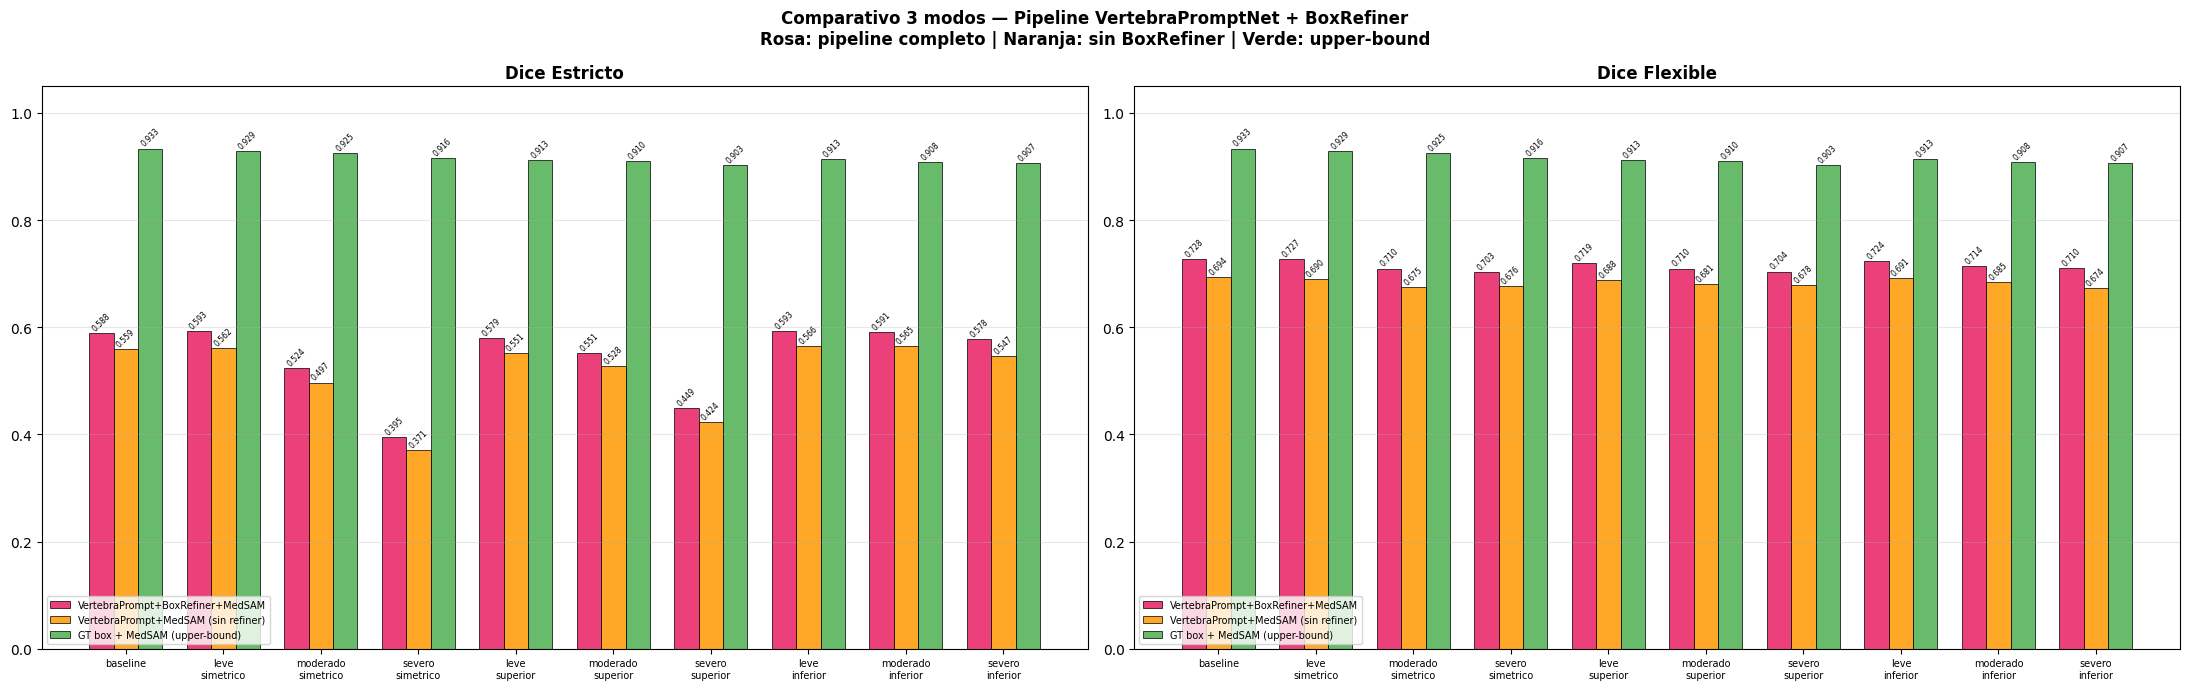

In [21]:
# ==== CELDA 18 — VISUALIZACIÓN: COMPARATIVO 3 MODOS ====
cfg_order=['baseline']+[c[0] for c in CROP_CONFIGS]
x=np.arange(len(cfg_order)); w=0.25
colores={'auto':'#E91E63','auto_norefiner':'#FF9800','gt_box':'#4CAF50'}
labels_modo={'auto':'VertebraPrompt+BoxRefiner+MedSAM',
             'auto_norefiner':'VertebraPrompt+MedSAM (sin refiner)',
             'gt_box':'GT box + MedSAM (upper-bound)'}

fig,axes=plt.subplots(1,2,figsize=(22,7))
for ai,(col,title) in enumerate([('dice_e_mean','Dice Estricto'),('dice_f_mean','Dice Flexible')]):
    ax=axes[ai]
    for mi,(modo,off) in enumerate(zip(MODOS,[-w,0,w])):
        sub=df_res[df_res['prompt_mode']==modo].set_index('cfg_nombre')
        vals=[float(sub.loc[c,col]) if c in sub.index and not pd.isna(sub.loc[c,col]) else 0 for c in cfg_order]
        bars=ax.bar(x+off,vals,w,label=labels_modo[modo],color=colores[modo],alpha=0.85,edgecolor='black',lw=0.6)
        for bar,val in zip(bars,vals):
            if val>0.01:
                ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.005,
                        f'{val:.3f}',ha='center',fontsize=5.5,rotation=45)
    ax.set_xticks(x); ax.set_xticklabels([c.replace('_','\n') for c in cfg_order],fontsize=7)
    ax.set_title(title,fontsize=12,weight='bold'); ax.legend(fontsize=7,loc='lower left')
    ax.grid(axis='y',alpha=0.3); ax.set_ylim(0,1.05)

plt.suptitle('Comparativo 3 modos — Pipeline VertebraPromptNet + BoxRefiner\n'
             'Rosa: pipeline completo | Naranja: sin BoxRefiner | Verde: upper-bound',
             fontsize=12,weight='bold')
plt.tight_layout()
plt.savefig(str(ROBUST_DIR/'comparativo_3modos.png'),dpi=150,bbox_inches='tight')
plt.show()


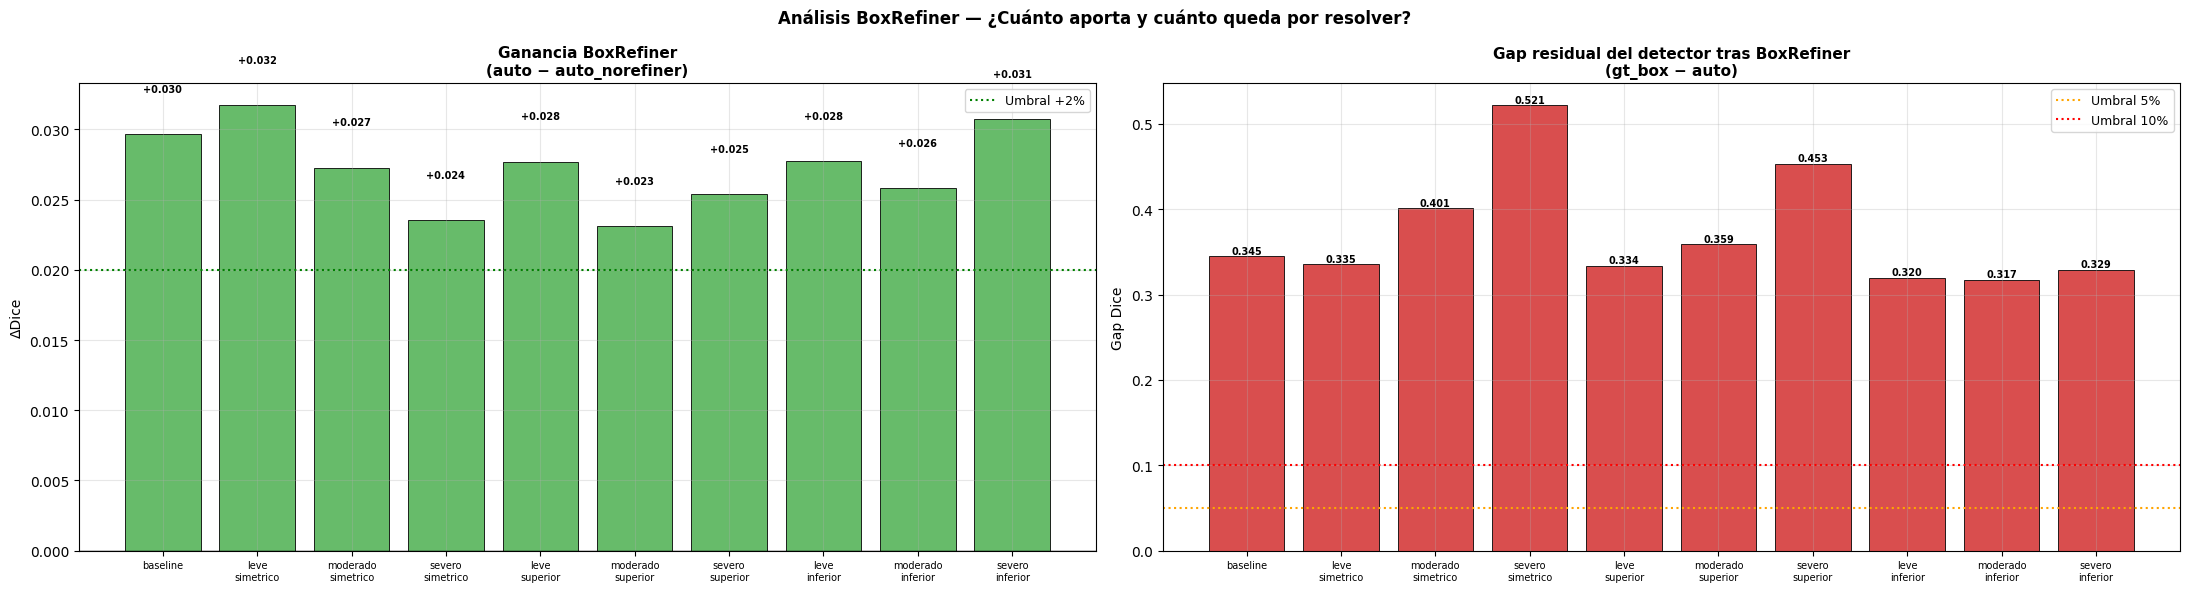


=== GANANCIA BoxRefiner POR CONFIGURACIÓN ===
  baseline                      ganancia=+0.0296  gap_residual=0.3451  ✅ Positivo
  leve_simetrico                ganancia=+0.0317  gap_residual=0.3355  ✅ Positivo
  moderado_simetrico            ganancia=+0.0273  gap_residual=0.4012  ✅ Positivo
  severo_simetrico              ganancia=+0.0236  gap_residual=0.5215  ✅ Positivo
  leve_superior                 ganancia=+0.0277  gap_residual=0.3336  ✅ Positivo
  moderado_superior             ganancia=+0.0231  gap_residual=0.3589  ✅ Positivo
  severo_superior               ganancia=+0.0254  gap_residual=0.4535  ✅ Positivo
  leve_inferior                 ganancia=+0.0278  gap_residual=0.3198  ✅ Positivo
  moderado_inferior             ganancia=+0.0258  gap_residual=0.3170  ✅ Positivo
  severo_inferior               ganancia=+0.0307  gap_residual=0.3293  ✅ Positivo


In [22]:
# ==== CELDA 19 — GANANCIA DEL BoxRefiner ====
# Cuantifica cuánto aporta el BoxRefiner respecto a no usarlo
cfg_order=['baseline']+[c[0] for c in CROP_CONFIGS]
da_auto=df_res[df_res['prompt_mode']=='auto'].set_index('cfg_nombre')
da_nore=df_res[df_res['prompt_mode']=='auto_norefiner'].set_index('cfg_nombre')
da_gt  =df_res[df_res['prompt_mode']=='gt_box'].set_index('cfg_nombre')

gain_refiner=[]
gap_detector=[]
for c in cfg_order:
    d_auto=float(da_auto.loc[c,'dice_e_mean']) if c in da_auto.index else np.nan
    d_nore=float(da_nore.loc[c,'dice_e_mean']) if c in da_nore.index else np.nan
    d_gt  =float(da_gt.loc[c,'dice_e_mean'])   if c in da_gt.index   else np.nan
    gain_refiner.append(d_auto-d_nore if np.isfinite(d_auto) and np.isfinite(d_nore) else np.nan)
    gap_detector.append(d_gt-d_auto   if np.isfinite(d_gt)   and np.isfinite(d_auto) else np.nan)

x=np.arange(len(cfg_order)); w=0.35
fig,axes=plt.subplots(1,2,figsize=(22,6))

# Ganancia BoxRefiner
bc1=[('#4CAF50' if g>0.01 else '#FF5722' if (g is not None and np.isfinite(g) and g<-0.01) else '#9E9E9E')
     for g in gain_refiner]
axes[0].bar(x,[g if np.isfinite(g) else 0 for g in gain_refiner],color=bc1,alpha=0.85,edgecolor='black',lw=0.7)
axes[0].axhline(0,color='black',lw=1)
axes[0].axhline(0.02,color='green',ls=':',lw=1.5,label='Umbral +2%')
axes[0].set_xticks(x); axes[0].set_xticklabels([c.replace('_','\n') for c in cfg_order],fontsize=7)
axes[0].set_title('Ganancia BoxRefiner\n(auto − auto_norefiner)',fontsize=11,weight='bold')
axes[0].set_ylabel('ΔDice'); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
for bar,val in zip(axes[0].patches,gain_refiner):
    if np.isfinite(val):
        axes[0].text(bar.get_x()+bar.get_width()/2,
                     bar.get_height()+(0.003 if val>=0 else -0.012),
                     f'{val:+.3f}',ha='center',fontsize=7,weight='bold')

# Gap residual del detector
bc2=[('#d32f2f' if g>0.10 else '#ff9800' if g>0.05 else '#4caf50')
     if np.isfinite(g) else '#ccc' for g in gap_detector]
axes[1].bar(x,[g if np.isfinite(g) else 0 for g in gap_detector],color=bc2,alpha=0.85,edgecolor='black',lw=0.7)
axes[1].axhline(0.05,color='orange',ls=':',lw=1.5,label='Umbral 5%')
axes[1].axhline(0.10,color='red',ls=':',lw=1.5,label='Umbral 10%')
axes[1].set_xticks(x); axes[1].set_xticklabels([c.replace('_','\n') for c in cfg_order],fontsize=7)
axes[1].set_title('Gap residual del detector tras BoxRefiner\n(gt_box − auto)',fontsize=11,weight='bold')
axes[1].set_ylabel('Gap Dice'); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
for bar,val in zip(axes[1].patches,gap_detector):
    if np.isfinite(val):
        axes[1].text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.003,
                     f'{val:.3f}',ha='center',fontsize=7,weight='bold')

plt.suptitle('Análisis BoxRefiner — ¿Cuánto aporta y cuánto queda por resolver?',
             fontsize=12,weight='bold')
plt.tight_layout()
plt.savefig(str(ROBUST_DIR/'analisis_boxrefiner.png'),dpi=150,bbox_inches='tight')
plt.show()

print('\n=== GANANCIA BoxRefiner POR CONFIGURACIÓN ===')
for cfg,g,gd in zip(cfg_order,gain_refiner,gap_detector):
    if np.isfinite(g):
        nivel='✅ Positivo' if g>0.01 else '➖ Neutro' if g>-0.01 else '⚠️ Negativo'
        print(f'  {cfg:28s}  ganancia={g:+.4f}  gap_residual={gd:.4f}  {nivel}')


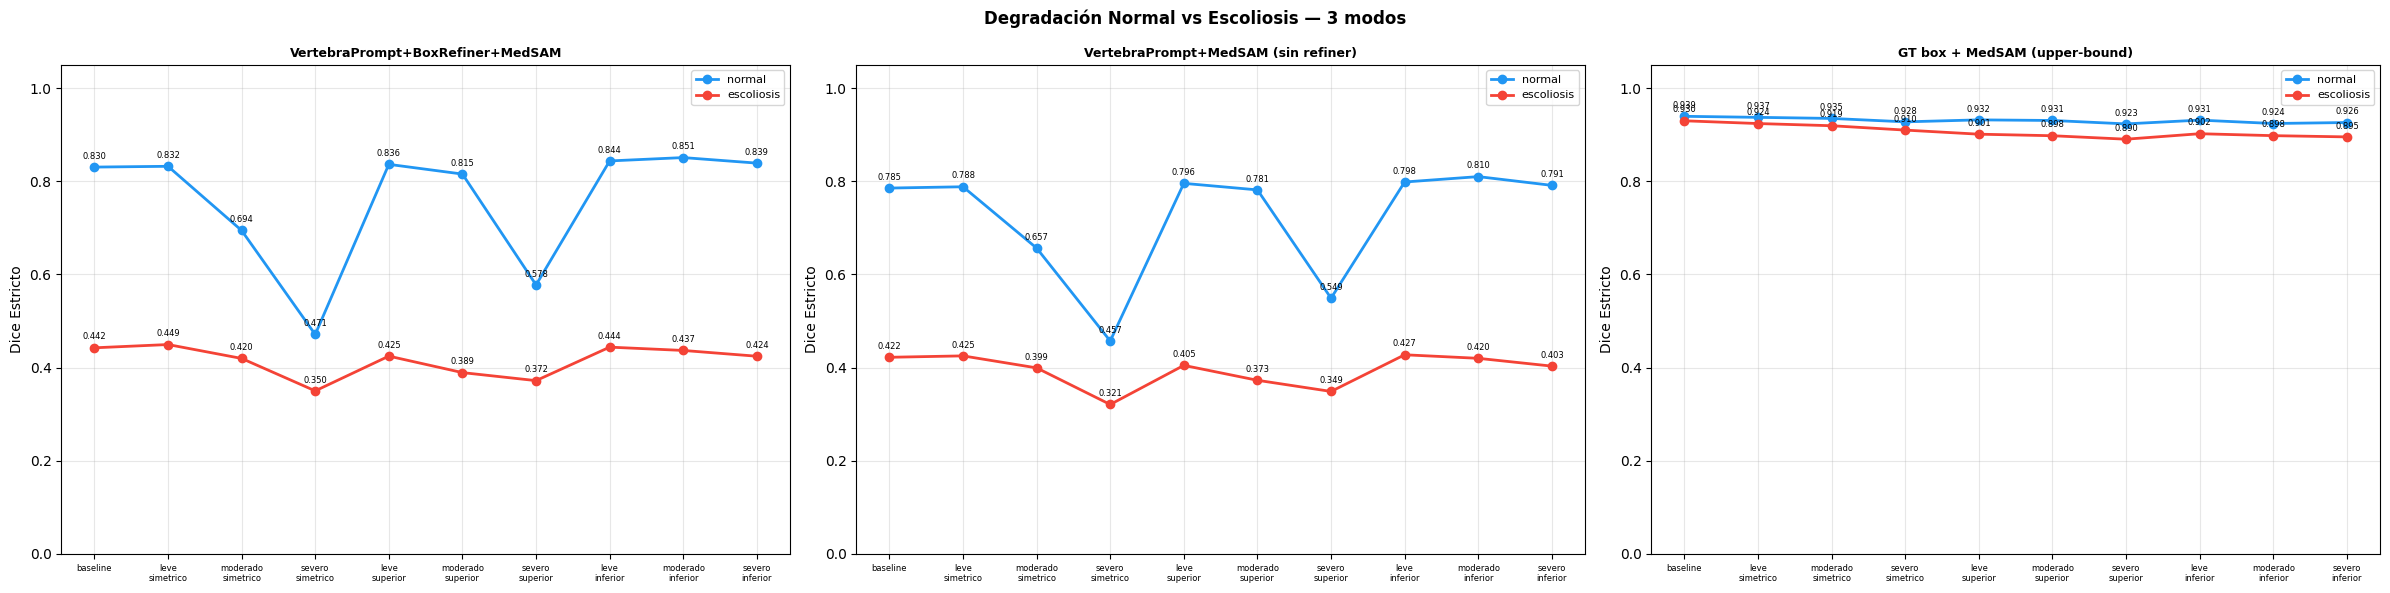

In [23]:
# ==== CELDA 20 — NORMAL vs ESCOLIOSIS POR MODO ====
cfg_order=['baseline']+[c[0] for c in CROP_CONFIGS]
fig,axes=plt.subplots(1,3,figsize=(24,6))
for ax,modo in zip(axes,MODOS):
    sub=df_res_tipo[df_res_tipo['prompt_mode']==modo]
    for tipo,color in [('normal','#2196F3'),('escoliosis','#F44336')]:
        vals=[]
        for cfg in cfg_order:
            row=sub[(sub['cfg_nombre']==cfg)&(sub['tipo']==tipo)]
            vals.append(float(row['dice_e_mean'].iloc[0]) if len(row) else np.nan)
        ax.plot(range(len(cfg_order)),vals,marker='o',label=tipo,color=color,lw=2)
        for xi,v in enumerate(vals):
            if not np.isnan(v): ax.annotate(f'{v:.3f}',(xi,v),xytext=(0,6),
                textcoords='offset points',ha='center',fontsize=6)
    ax.set_xticks(range(len(cfg_order)))
    ax.set_xticklabels([c.replace('_','\n') for c in cfg_order],fontsize=6)
    ax.set_ylim(0,1.05); ax.set_ylabel('Dice Estricto')
    ax.set_title(labels_modo[modo],fontsize=9,weight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('Degradación Normal vs Escoliosis — 3 modos',fontsize=12,weight='bold')
plt.tight_layout()
plt.savefig(str(ROBUST_DIR/'normal_vs_escoliosis.png'),dpi=150,bbox_inches='tight')
plt.show()


In [24]:
# ==== CELDA 21 — RESUMEN FINAL ====
print('='*70)
print('RESUMEN — Pipeline VertebraPromptNet + BoxRefiner + MedSAM')
print('='*70)
print(f'Split: {SPLIT_EVAL}  |  Pacientes: {len(PIDS_EVAL)}')
cfg_order=['baseline']+[c[0] for c in CROP_CONFIGS]

for modo in MODOS:
    labels_m={'auto':'🤖 VertebraPrompt+BoxRefiner+MedSAM',
              'auto_norefiner':'🔧 VertebraPrompt+MedSAM (sin refiner)',
              'gt_box':'📌 GT box+MedSAM (upper-bound)'}
    print(f'\n{labels_m[modo]}')
    sub=df_res[df_res['prompt_mode']==modo].set_index('cfg_nombre')
    bd=float(sub.loc['baseline','dice_e_mean']) if 'baseline' in sub.index else np.nan
    print(f'  Baseline Dice estricto : {bd:.4f}')
    for cfg in cfg_order[1:]:
        if cfg not in sub.index: continue
        d=float(sub.loc[cfg,'dice_e_mean'])
        dg=float(sub.loc[cfg,'degradacion_pct']) if 'degradacion_pct' in sub.columns else np.nan
        ha=float(sub.loc[cfg,'hallucination_rate']) if 'hallucination_rate' in sub.columns else np.nan
        print(f'  {cfg:28s}  Dice={d:.4f}  Degrad={dg:+.1f}%  Aluc={ha:.2f}')

# Comparativo rápido con pipeline anterior (NN-SAM)
print('\n' + '='*70)
print('REFERENCIA: Pipeline anterior (CenterNetLite + MedSAM)')
print('  Baseline auto  : 0.4954  (38 pacientes test)')
print('  Baseline gt_box: 0.9316')
print('  Gap detector   : ~0.436')
print('\nComparar con los valores de arriba para medir mejora del BoxRefiner.')
print('='*70)

print('\nArchivos generados:')
for f in sorted(list(ROBUST_DIR.glob('*.csv'))+list(ROBUST_DIR.glob('*.png'))):
    print(f'  {f.name}')


RESUMEN — Pipeline VertebraPromptNet + BoxRefiner + MedSAM
Split: test  |  Pacientes: 38

🤖 VertebraPrompt+BoxRefiner+MedSAM
  Baseline Dice estricto : 0.5884
  leve_simetrico                Dice=0.5935  Degrad=-0.9%  Aluc=2.50
  moderado_simetrico            Dice=0.5240  Degrad=+10.9%  Aluc=2.63
  severo_simetrico              Dice=0.3950  Degrad=+32.9%  Aluc=3.95
  leve_superior                 Dice=0.5790  Degrad=+1.6%  Aluc=2.55
  moderado_superior             Dice=0.5513  Degrad=+6.3%  Aluc=2.66
  severo_superior               Dice=0.4491  Degrad=+23.7%  Aluc=3.42
  leve_inferior                 Dice=0.5933  Degrad=-0.8%  Aluc=2.45
  moderado_inferior             Dice=0.5908  Degrad=-0.4%  Aluc=2.32
  severo_inferior               Dice=0.5775  Degrad=+1.8%  Aluc=2.50

🔧 VertebraPrompt+MedSAM (sin refiner)
  Baseline Dice estricto : 0.5587
  leve_simetrico                Dice=0.5618  Degrad=-0.5%  Aluc=2.32
  moderado_simetrico            Dice=0.4968  Degrad=+11.1%  Aluc=2.45
  sev